# 03 — Kuhn Poker (2 jugadores): CFR e ISMCTS

**Obligatorio 2 — Sistemas Multiagente**

Kuhn Poker es el juego de **información imperfecta** más simple con equilibrio de
Nash conocido. Baraja de 3 cartas (J, Q, K), cada jugador recibe 1 carta oculta,
acciones *pass* (p) / *bet* (b).

- **CFR** (Counterfactual Regret Minimization) — converge al **equilibrio de Nash**
  recorriendo el árbol y minimizando *regret*.
- **ISMCTS** (Information Set MCTS) — MCTS sobre *information sets* con
  *determinización* del estado oculto.

Resultados teóricos conocidos:
- El **valor del juego para el jugador 0** (que abre) es **−1/18 ≈ −0.0556**.
- La estrategia de Nash hace que con la **J** se apueste como *farol* con prob.
  ~1/3, y con la **K** se apueste siempre.

In [1]:
import sys, os
try:
    ROOT = os.path.dirname(__vsc_ipynb_file__)   # VS Code
except NameError:
    ROOT = os.getcwd()                            # Jupyter / fallback
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print("Raiz del proyecto:", ROOT)

Raiz del proyecto: C:\Users\joaco\Documents\ort\semestre_3\obligatorio2-sma\obligatorio_2_joaco


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
sns.set_theme(style="whitegrid", palette="deep")

from games.kuhn import KuhnPoker
from agents.cfr import CounterFactualRegret
from agents.ismcts import ISMCTS
from agents.agent_random import RandomAgent
from utils import run_games, win_draw_loss, matchup_both_sides

np.random.seed(42)
NASH_P0 = -1/18
print("Valor de Nash para P0:", round(NASH_P0, 4))

Valor de Nash para P0: -0.0556


## 1. Convergencia de CFR al equilibrio de Nash

Entrenamos dos agentes CFR en *self-play*, midiendo cada cierto número de
iteraciones la recompensa media del jugador 0 (debe acercarse a −1/18) y la
evolución de la probabilidad de apostar en *information sets* clave.

In [3]:
game = KuhnPoker(initial_player=0)
cfr0 = CounterFactualRegret(game, 'agent_0')
cfr1 = CounterFactualRegret(game, 'agent_1')

# N_EVAL alto a proposito: la recompensa media por partida tiene varianza ~0.06 con
# pocos juegos, asi que para LEER el valor final cerca del Nash (-1/18) hacen falta
# muchas partidas de evaluacion. (El metodo cfr0 vs cfr1 es el correcto; verificamos
# que con suficientes juegos el valor cae sobre -0.0556.)
CHECK, TOTAL, N_EVAL = 250, 6000, 4000
iters, mean_rewards = [], []
pol_track = defaultdict(list)          # obs -> lista de P(bet)
track_obs = {'0': 'J (abre)', '2': 'K (abre)', '0p': 'J tras pass', '2p': 'K tras pass'}

for i in range(0, TOTAL, CHECK):
    cfr0.train(niter=CHECK)
    cfr1.train(niter=CHECK)
    res = run_games(game, {'agent_0': cfr0, 'agent_1': cfr1}, N_EVAL)
    iters.append(i + CHECK)
    mean_rewards.append(res['mean_reward'])
    for obs in track_obs:
        if obs in cfr0.node_dict:
            pol_track[obs].append(cfr0.node_dict[obs].learned_policy[1])  # P(bet)
print("Info sets aprendidos por P0:", len(cfr0.node_dict))
print("Recompensa media final P0:", round(mean_rewards[-1], 4), "(Nash =", round(NASH_P0,4), ")")

Info sets aprendidos por P0: 12
Recompensa media final P0: -0.035 (Nash = -0.0556 )


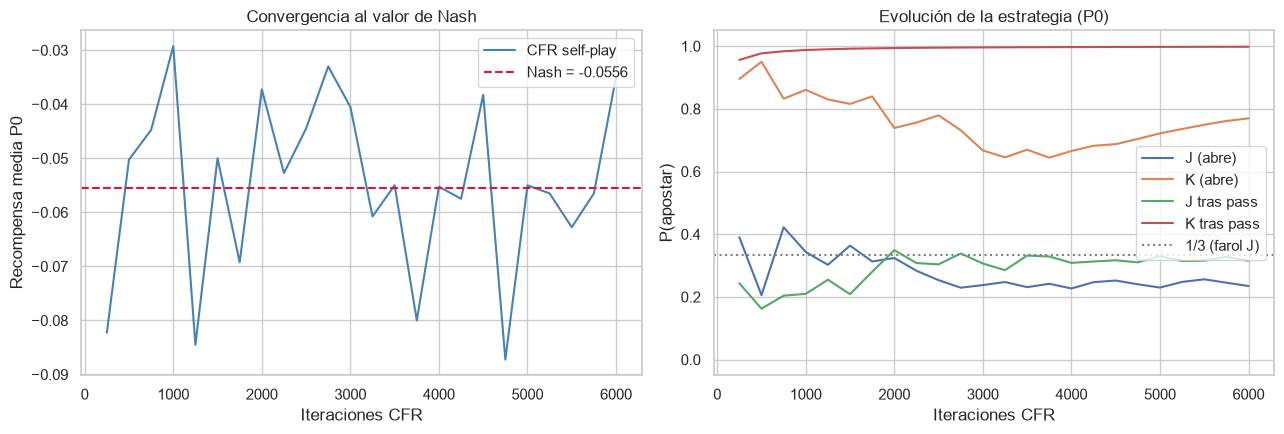

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(iters, mean_rewards, '-', color='steelblue', label='CFR self-play')
ax[0].axhline(NASH_P0, color='crimson', ls='--', label=f'Nash = {NASH_P0:.4f}')
ax[0].set(xlabel='Iteraciones CFR', ylabel='Recompensa media P0', title='Convergencia al valor de Nash')
ax[0].legend()
for obs, lbl in track_obs.items():
    if pol_track[obs]:
        ax[1].plot(iters[:len(pol_track[obs])], pol_track[obs], '-', label=lbl)
ax[1].axhline(1/3, color='gray', ls=':', label='1/3 (farol J)')
ax[1].set(xlabel='Iteraciones CFR', ylabel='P(apostar)', title='Evolución de la estrategia (P0)', ylim=(-0.05, 1.05))
ax[1].legend()
plt.tight_layout(); plt.show()

## 2. Estrategia final aprendida vs teoría

Probabilidad de **apostar** en cada *information set* (carta + historia).

In [5]:
card = {'0': 'J', '1': 'Q', '2': 'K'}
rows = []
for obs in sorted(cfr0.node_dict):
    node = cfr0.node_dict[obs]
    rows.append({'info_set': obs, 'carta': card.get(obs[0], '?'),
                 'historia': obs[1:] or '(inicio)',
                 'P(pass)': node.learned_policy[0], 'P(bet)': node.learned_policy[1]})
df_pol = pd.DataFrame(rows)
df_pol.round(3)

,info_set,carta,historia,P(pass),P(bet)
0,0,J,(inicio),0.765,0.235
1,0b,J,b,1.000,0.000
2,0p,J,p,0.685,0.315
3,0pb,J,pb,1.000,0.000
4,1,Q,(inicio),0.995,0.005
5,1b,Q,b,0.646,0.354
6,1p,Q,p,0.995,0.005
7,1pb,Q,pb,0.408,0.592
8,2,K,(inicio),0.230,0.770
9,2b,K,b,0.000,1.000


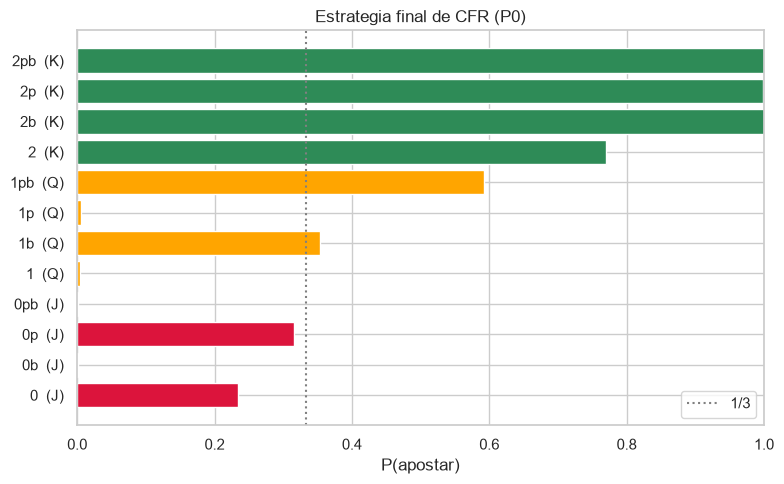

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'J': 'crimson', 'Q': 'orange', 'K': 'seagreen'}
ax.barh(df_pol['info_set'] + '  (' + df_pol['carta'] + ')', df_pol['P(bet)'],
        color=[colors.get(x, 'gray') for x in df_pol['carta']])
ax.axvline(1/3, color='gray', ls=':', label='1/3')
ax.set(xlabel='P(apostar)', title='Estrategia final de CFR (P0)', xlim=(0, 1)); ax.legend()
plt.tight_layout(); plt.show()

## 3. CFR vs ISMCTS vs Random

Entrenamos un CFR y lo comparamos con ISMCTS (variando simulaciones) y con un
agente aleatorio. Las recompensas se promedian jugando **ambas posiciones**.

In [7]:
def make_cfr(g, a, niter=5000):
    ag = CounterFactualRegret(g, a); ag.train(niter=niter); return ag

# Lineas base vs Random
# initial_player=0 fijo: matchup_both_sides ya neutraliza la posicion intercambiando
# que agente ocupa agent_0/agent_1; si dejamos initial_player=None, KuhnPoker lo
# sortea UNA sola vez por instancia (no por partida) y ese sorteo queda fijo para
# las n_games de cada lado, lo que confunde "quien abre" sin agregar variabilidad real.
base = []
for name, mk in [('CFR', lambda g, a: make_cfr(g, a)),
                 ('ISMCTS(400)', lambda g, a: ISMCTS(g, a, simulations=400)),
                 ('Random', lambda g, a: RandomAgent(g, a))]:
    res = matchup_both_sides(lambda: KuhnPoker(initial_player=0), make_a=mk,
                             make_b=lambda g, a: RandomAgent(g, a), n_games=150)
    base.append({'agente': name, 'reward_vs_random': res['mean_reward_A'], 'time': res['time']})
pd.DataFrame(base).round(3)

,agente,reward_vs_random,time
0,CFR,0.130,0.120
1,ISMCTS(400),0.327,57.085
2,Random,0.107,0.081


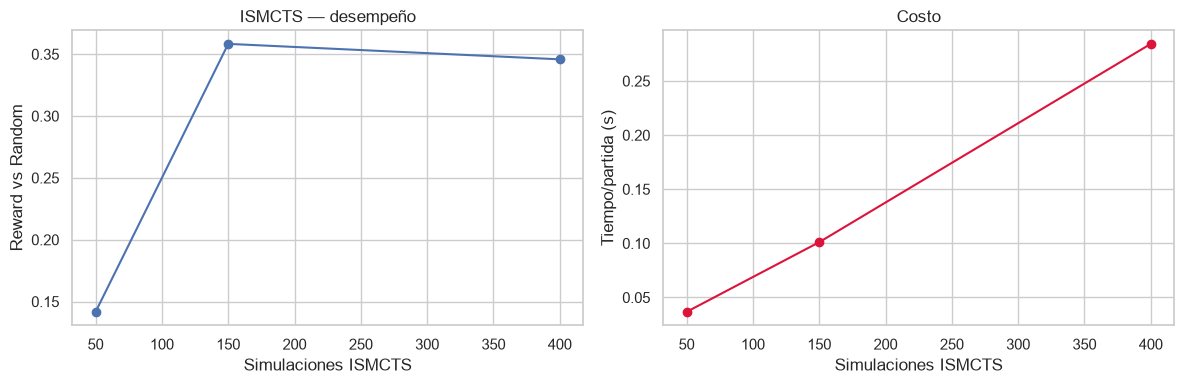

,sims,reward_vs_random,time_per_game
0,50,0.142,0.037
1,150,0.358,0.101
2,400,0.346,0.284


In [8]:
# ISMCTS: barrido de simulaciones (vs Random)
rows = []
for s in [50, 150, 400]:
    res = matchup_both_sides(lambda: KuhnPoker(initial_player=0),
        make_a=lambda g, a, s=s: ISMCTS(g, a, simulations=s),
        make_b=lambda g, a: RandomAgent(g, a), n_games=120)
    rows.append({'sims': s, 'reward_vs_random': res['mean_reward_A'], 'time_per_game': res['time'] / 240})
df_is = pd.DataFrame(rows)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df_is.sims, df_is.reward_vs_random, 'o-'); ax[0].set(xlabel='Simulaciones ISMCTS', ylabel='Reward vs Random', title='ISMCTS — desempeño')
ax[1].plot(df_is.sims, df_is.time_per_game, 'o-', color='crimson'); ax[1].set(xlabel='Simulaciones ISMCTS', ylabel='Tiempo/partida (s)', title='Costo')
plt.tight_layout(); plt.show()
df_is.round(3)

In [9]:
# Enfrentamiento directo CFR vs ISMCTS (ambas posiciones, desde la optica de CFR)
res = matchup_both_sides(lambda: KuhnPoker(initial_player=0),
    make_a=lambda g, a: make_cfr(g, a),
    make_b=lambda g, a: ISMCTS(g, a, simulations=400), n_games=150)
print("CFR vs ISMCTS(400) — reward medio de CFR (ambas posiciones):", round(res['mean_reward_A'], 3))
print("  como P0:", round(res['mean_p0'], 3), "| como P1:", round(res['mean_p1'], 3))

CFR vs ISMCTS(400) — reward medio de CFR (ambas posiciones): 0.18
  como P0: -0.04 | como P1: 0.4


## 4. Efecto de la posición

En Kuhn, abrir (jugador 0) es una **desventaja** (valor de Nash negativo).
Comparamos la recompensa de CFR según la posición.

In [10]:
res = matchup_both_sides(lambda: KuhnPoker(initial_player=0), make_a=lambda g, a: make_cfr(g, a),
                         make_b=lambda g, a: make_cfr(g, a), n_games=2000)
print("CFR vs CFR  | reward P0:", round(res['mean_p0'], 4),
      "| reward P1:", round(res['mean_p1'], 4), "| Nash P0 =", round(NASH_P0, 4))

CFR vs CFR  | reward P0: -0.111 | reward P1: 0.0125 | Nash P0 = -0.0556


## Conclusiones — Kuhn Poker (2P)

- **CFR converge al equilibrio de Nash**: la recompensa media de P0 se estabiliza
  cerca de **−1/18** y la estrategia reproduce el patrón teórico (farol con J ~1/3,
  *value bet* con K).
- **ISMCTS** mejora con más simulaciones y vence a Random, pero al no resolver el
  juego no alcanza la precisión de CFR ni explota igual de bien al rival débil.
- La **posición importa**: abrir es desventajoso, consistente con el valor negativo
  del juego para P0.